In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, matthews_corrcoef, confusion_matrix
from imblearn.over_sampling import SMOTE, ADASYN, RandomOverSampler

from imblearn.pipeline import Pipeline 
import warnings
warnings.filterwarnings('ignore')

In [2]:
X_gen, y_gen = make_classification(
    n_samples=2000, n_features=10, n_informative=6, n_redundant=2,
    n_clusters_per_class=2, weights=[0.85, 0.15], class_sep=0.6, 
    flip_y=0.05, random_state=42
)

clases, conteos = np.unique(y_gen, return_counts=True)
ratio_original = conteos[1] / conteos[0]

In [7]:
#FUNCIONES Y SCORERS PERSONALIZADOS
def calcular_gps(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        tnr = tn / (tn + fp) if (tn + fp) > 0 else 0
        if tpr + tnr == 0: return 0.0
        return 2 * (tpr * tnr) / (tpr + tnr)
    return 0.0

mcc_scorer = make_scorer(matthews_corrcoef)
gps_scorer = make_scorer(calcular_gps)
scoring_dict = {'MCC': mcc_scorer, 'GPS': gps_scorer}

# CONFIGURAR EL MOTOR DE VALIDACIÓN CRUZADA
cv_estrategia = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clasificador_base = RandomForestClassifier(n_estimators=100, random_state=0, n_jobs=-1)

# BUCLE PRINCIPAL DE ESCANEO
samplers_dict = {'SMOTE': SMOTE, 'ADASYN': ADASYN, 'ROS': RandomOverSampler}
ratios_a_probar = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
resultados_cv = []

print("Iniciando con Validación Cruzada (5 Folds)...")

# Evaluar Baseline (Rendimiento del dataset original sin balancear)
cv_base = cross_validate(clasificador_base, X_gen, y_gen, cv=cv_estrategia, scoring=scoring_dict)
base_mcc_mean, base_mcc_std = np.mean(cv_base['test_MCC']), np.std(cv_base['test_MCC'])
base_gps_mean, base_gps_std = np.mean(cv_base['test_GPS']), np.std(cv_base['test_GPS'])

for nombre, SamplerClass in samplers_dict.items():
    # Insertar el Baseline como punto de partida para la gráfica
    resultados_cv.append({
        'Sampler': nombre, 'Ratio': round(ratio_original, 3),
        'MCC_Medio': base_mcc_mean, 'MCC_Std': base_mcc_std,
        'GPS_Medio': base_gps_mean, 'GPS_Std': base_gps_std
    })
    
    for r in ratios_a_probar:
        if r <= ratio_original: continue # Saltar ratios ilógicos
        
        # El Pipeline asegura que SMOTE/ADASYN/ROS solo actúe en el fold de entrenamiento
        modelo_pipeline = Pipeline([
            ('sampler', SamplerClass(sampling_strategy=r, random_state=42)),
            ('clasificador', clasificador_base)
        ])
        
        try:
            cv_scores = cross_validate(modelo_pipeline, X_gen, y_gen, cv=cv_estrategia, scoring=scoring_dict)
            resultados_cv.append({
                'Sampler': nombre, 'Ratio': r,
                'MCC_Medio': np.mean(cv_scores['test_MCC']), 'MCC_Std': np.std(cv_scores['test_MCC']),
                'GPS_Medio': np.mean(cv_scores['test_GPS']), 'GPS_Std': np.std(cv_scores['test_GPS'])
            })
        except Exception as e:
            pass

df_cv = pd.DataFrame(resultados_cv)
print("Completado.")

Iniciando con Validación Cruzada (5 Folds)...
Completado.


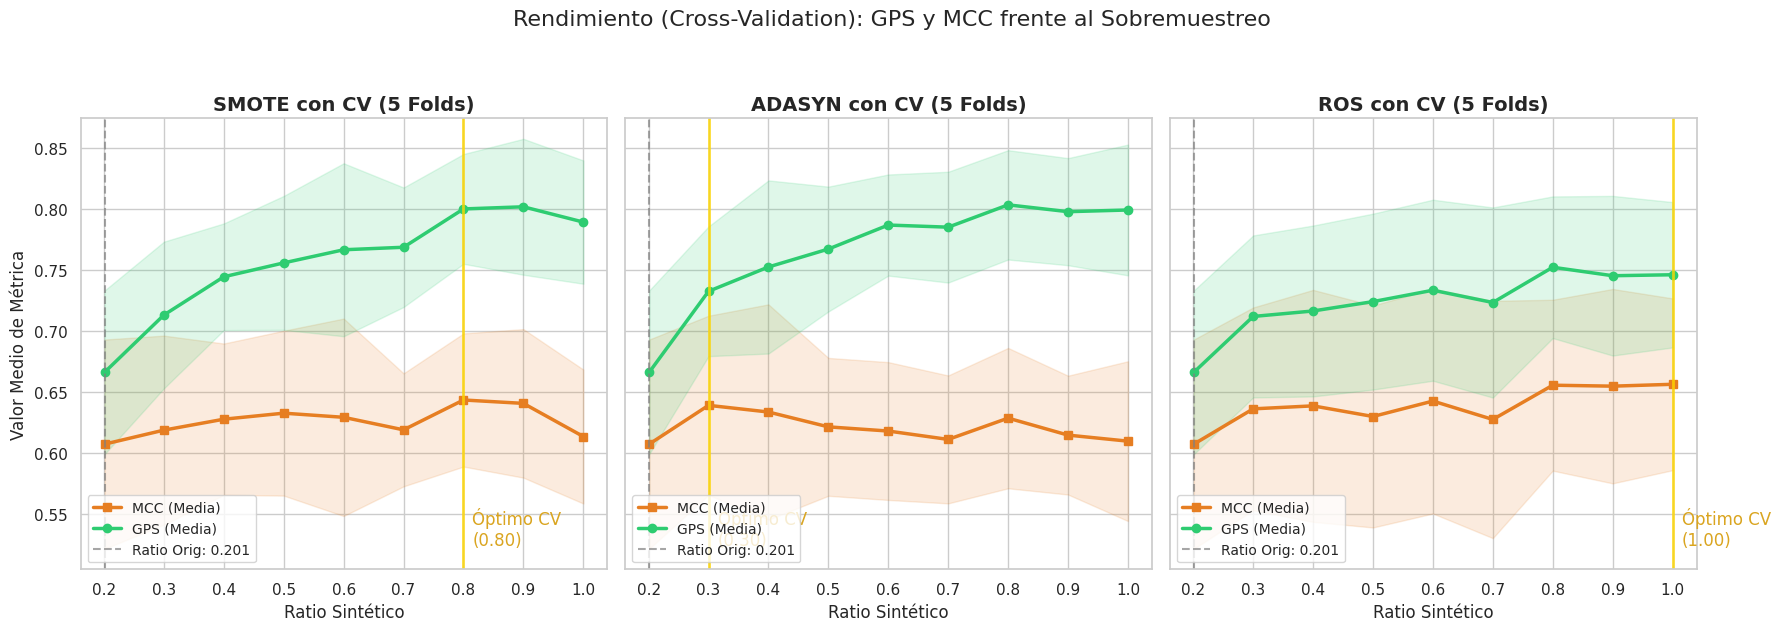

In [10]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

for i, nombre in enumerate(['SMOTE', 'ADASYN', 'ROS']):
    ax = axes[i]
    df_sub = df_cv[df_cv['Sampler'] == nombre].reset_index(drop=True)
    
    # Dibujar la curva MCC y su "sombra" de desviación estándar
    ax.plot(df_sub['Ratio'], df_sub['MCC_Medio'], marker='s', color='#e67e22', linewidth=2.5, label='MCC (Media)')
    ax.fill_between(df_sub['Ratio'], df_sub['MCC_Medio'] - df_sub['MCC_Std'], df_sub['MCC_Medio'] + df_sub['MCC_Std'], color='#e67e22', alpha=0.15)
    
    # Dibujar la curva GPS y su "sombra"
    ax.plot(df_sub['Ratio'], df_sub['GPS_Medio'], marker='o', color='#2ecc71', linewidth=2.5, label='GPS (Media)')
    ax.fill_between(df_sub['Ratio'], df_sub['GPS_Medio'] - df_sub['GPS_Std'], df_sub['GPS_Medio'] + df_sub['GPS_Std'], color='#2ecc71', alpha=0.15)
    
    # Marcar Baseline
    ax.axvline(x=ratio_original, color='gray', linestyle='--', alpha=0.7, label=f'Ratio Orig: {ratio_original:.3f}')
    
    # Encontrar el Óptimo Validado Cruzado
    mejor_idx = df_sub['MCC_Medio'].idxmax()
    mejor_ratio = df_sub.loc[mejor_idx, 'Ratio']
    ax.axvline(x=mejor_ratio, color='gold', linestyle='-', linewidth=2, alpha=0.8)
    ax.text(mejor_ratio + 0.015, ax.get_ylim()[0] + 0.02, f'Óptimo CV\n({mejor_ratio:.2f})', color='goldenrod')
    
    ax.set_title(f'{nombre} con CV (5 Folds)', fontsize=14, fontweight='bold')
    ax.set_xlabel('Ratio Sintético', fontsize=12)
    if i == 0: ax.set_ylabel('Valor Medio de Métrica', fontsize=12)
    ax.legend(loc='lower left', fontsize=10)

plt.suptitle('Rendimiento (Cross-Validation): GPS y MCC frente al Sobremuestreo', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()